In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
       # print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D, MaxPool2D,
                                      BatchNormalization, AveragePooling2D,
                                      GlobalAveragePooling2D, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121

2026-04-01 20:06:43.825176: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775074004.289088      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775074004.412847      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775074005.405171      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775074005.405211      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775074005.405215      17 computation_placer.cc:177] computation placer alr

In [3]:
SIZE = 128        # ✅ Single SIZE used everywhere
N_ch = 3
BATCH_SIZE = 16
EPOCHS = 25
SEED = 42

In [4]:
disease_types = [
    'Pepper__bell___Bacterial_spot','Pepper__bell___healthy',
    'Potato___Early_blight','Potato___Late_blight','Potato___healthy',
    'Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight',
    'Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]
data_dir = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'

train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(data_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID', 'Disease Type'])
train = train.sample(frac=1, random_state=SEED)
train.index = np.arange(len(train))
print(f"Total images: {len(train)}")

Total images: 20639


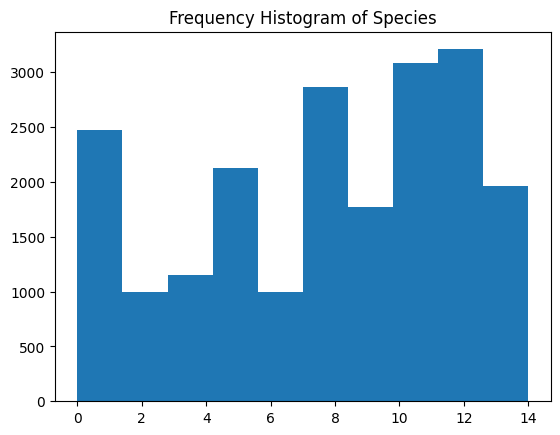

In [5]:
plt.hist(train['DiseaseID'])
plt.title('Frequency Histogram of Species')
plt.show()

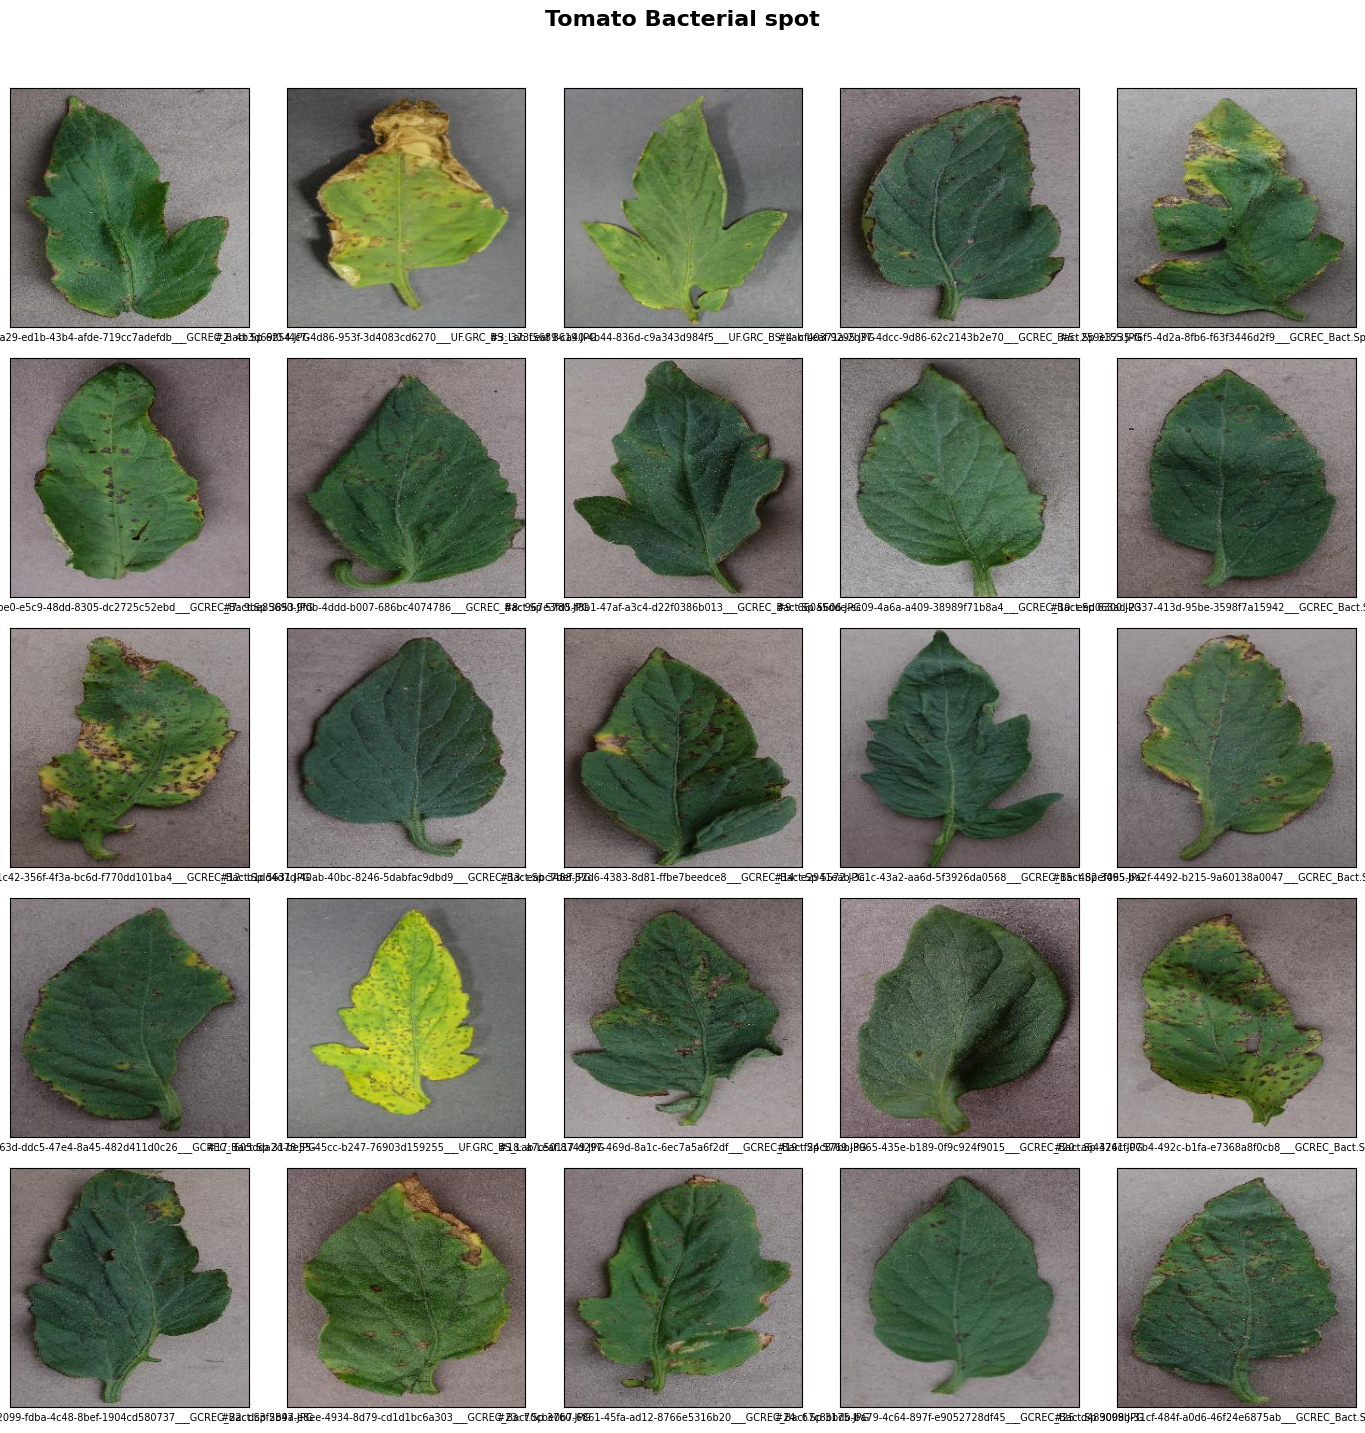

In [6]:
def plot_defects(defect_types, rows, cols):
    fig, ax = plt.subplots(rows, cols, figsize=(14, 14))
    fig.suptitle(defect_types.replace('_', ' '), fontsize=16, fontweight='bold', y=1.02)
    defect_files = train['File'][train['Disease Type'] == defect_types].values
    n = 0
    for i in range(rows):
        for j in range(cols):
            image_path = os.path.join(data_dir, defect_files[n])
            img = cv2.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax[i, j].imshow(img)
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].set_xlabel(f"#{n+1}: {os.path.basename(defect_files[n])}", fontsize=7)
            n += 1
    plt.tight_layout()
    plt.show()

plot_defects('Tomato_Bacterial_spot', 5, 5)

In [7]:
X = np.zeros((len(train), SIZE, SIZE, N_ch))
for i, file in tqdm(enumerate(train['File'].values), total=len(train)):
    img = cv2.imread(os.path.join(data_dir, file))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (SIZE, SIZE))   # ✅ 128x128
        X[i] = img

X = X / 255.0  # Normalize
print(f"✅ X shape: {X.shape}")  # Must be (N, 128, 128, 3)

100%|██████████| 20639/20639 [03:01<00:00, 113.80it/s]


✅ X shape: (20639, 128, 128, 3)


In [8]:
y = train['DiseaseID'].values
Y = to_categorical(y, num_classes=15)

In [9]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"✅ X_train: {X_train.shape}")  # Must be (N, 128, 128, 3)
print(f"✅ X_val:   {X_val.shape}")

✅ X_train: (16511, 128, 128, 3)
✅ X_val:   (4128, 128, 128, 3)


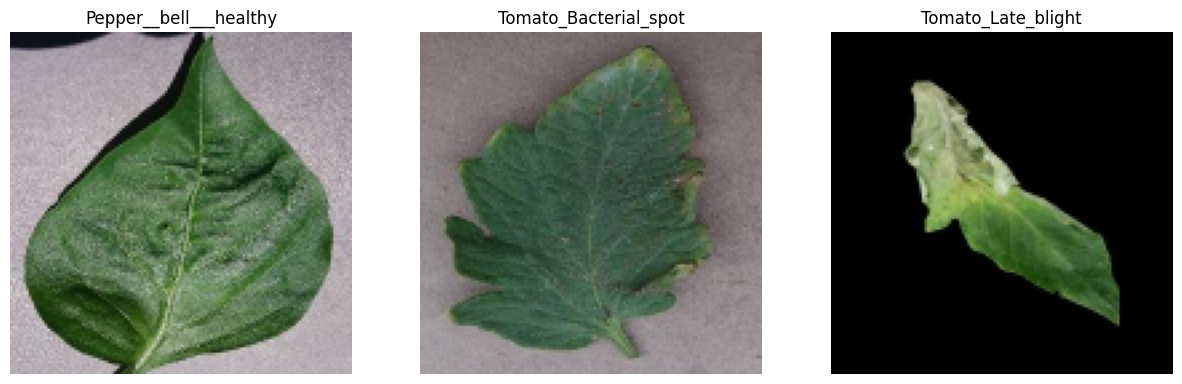

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    ax[i].set_axis_off()
    ax[i].imshow(X_train[i])
    ax[i].set_title(disease_types[np.argmax(Y_train[i])])
plt.show()

In [11]:
def build_densenet():
    densenet = DenseNet121(weights=None, include_top=False)
    input = Input(shape=(SIZE, SIZE, N_ch))  # ✅ (128, 128, 3)
    x = Conv2D(3, (3, 3), padding='same')(input)
    x = densenet(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(15, activation='softmax', name='root')(x)
    model = Model(input, output)
    optimizer = Adam(learning_rate=0.002, beta_1=0.9, beta_2=0.999, epsilon=0.1)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.summary()
    return model


In [12]:
model = build_densenet()
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-5)
checkpoint = ModelCheckpoint('model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)

datagen = ImageDataGenerator(
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)
datagen.fit(X_train)

hist = model.fit(
    datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[annealer, checkpoint],
    validation_data=(X_val, Y_val)
)

2026-04-01 20:10:35.516380: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ root (Dense)                    │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,308,963 (27.88 MB)

 Trainable params: 7,222,755 (27.55 MB)

...

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2046s 2s/step - accuracy: 0.7625 - loss: 0.7165 - val_accuracy: 0.6705 - val_loss: 0.9839 - learning_rate: 0.0020
Epoch 8/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 32:15 2s/step - accuracy: 0.8750 - loss: 0.3890
Epoch 8: val_accuracy did not improve from 0.67054
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 144s 138ms/step - accuracy: 0.8750 - loss: 0.3890 - val_accuracy: 0.6696 - val_loss: 0.9556 - learning_rate: 0.0020
Epoch 9/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7994 - loss: 0.6038
Epoch 9: val_accuracy did not improve from 0.67054
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2009s 2s/step - accuracy: 0.7994 - loss: 0.6038 - val_accuracy: 0.6444 - val_loss: 1.2149 - learning_rate: 0.0020
Epoch 10/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 33:31 2s/step - accuracy: 1.0000 - loss: 0.1572
Epoch 10: val_accuracy did not improve from 0.67054
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 96s 91ms/step - accuracy: 1.0000 - loss: 0.1572 - val_accuracy: 0.6129 - val_loss: 1.3538 - learning_rate: 0.0

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2013s 2s/step - accuracy: 0.8457 - loss: 0.4730 - val_accuracy: 0.7001 - val_loss: 1.0985 - learning_rate: 0.0020
Epoch 12/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 31:13 2s/step - accuracy: 0.8125 - loss: 0.5977
Epoch 12: val_accuracy improved from 0.70010 to 0.73692, saving model to model.h5


1031/1031 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.8125 - loss: 0.5977 - val_accuracy: 0.7369 - val_loss: 0.9356 - learning_rate: 0.0020
Epoch 13/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8527 - loss: 0.4358
Epoch 13: val_accuracy did not improve from 0.73692
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 1979s 2s/step - accuracy: 0.8527 - loss: 0.4357 - val_accuracy: 0.5388 - val_loss: 2.4323 - learning_rate: 0.0020
Epoch 14/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 33:59 2s/step - accuracy: 1.0000 - loss: 0.1386
Epoch 14: val_accuracy did not improve from 0.73692
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 144s 138ms/step - accuracy: 1.0000 - loss: 0.1386 - val_accuracy: 0.5426 - val_loss: 2.3705 - learning_rate: 0.0020
Epoch 15/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8768 - loss: 0.3766
Epoch 15: val_accuracy did not improve from 0.73692
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2005s 2s/step - accuracy: 0.8768 - loss: 0.3766 - val_accuracy: 0.6999 - val_loss: 1.0996 - learning_rate: 0.

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2032s 2s/step - accuracy: 0.8855 - loss: 0.3482 - val_accuracy: 0.8537 - val_loss: 0.4854 - learning_rate: 0.0020
Epoch 18/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 29:30 2s/step - accuracy: 0.9375 - loss: 0.2028
Epoch 18: val_accuracy did not improve from 0.85368
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 92s 88ms/step - accuracy: 0.9375 - loss: 0.2028 - val_accuracy: 0.8411 - val_loss: 0.5504 - learning_rate: 0.0020
Epoch 19/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9000 - loss: 0.3083
Epoch 19: val_accuracy did not improve from 0.85368
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 1984s 2s/step - accuracy: 0.9000 - loss: 0.3083 - val_accuracy: 0.7999 - val_loss: 0.6203 - learning_rate: 0.0020
Epoch 20/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 36:20 2s/step - accuracy: 0.8125 - loss: 0.5048
Epoch 20: val_accuracy did not improve from 0.85368
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 144s 138ms/step - accuracy: 0.8125 - loss: 0.5048 - val_accuracy: 0.8006 - val_loss: 0.6130 - learning_rate:

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 98s 93ms/step - accuracy: 0.8750 - loss: 0.2628 - val_accuracy: 0.8670 - val_loss: 0.4123 - learning_rate: 0.0020
Epoch 23/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9076 - loss: 0.2790
Epoch 23: val_accuracy did not improve from 0.86701
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 1991s 2s/step - accuracy: 0.9076 - loss: 0.2790 - val_accuracy: 0.7432 - val_loss: 0.8804 - learning_rate: 0.0020
Epoch 24/25
   1/1031 ━━━━━━━━━━━━━━━━━━━━ 35:03 2s/step - accuracy: 0.9375 - loss: 0.1298
Epoch 24: val_accuracy did not improve from 0.86701
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 95s 90ms/step - accuracy: 0.9375 - loss: 0.1298 - val_accuracy: 0.7442 - val_loss: 0.8745 - learning_rate: 0.0020
Epoch 25/25
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9167 - loss: 0.2455
Epoch 25: val_accuracy did not improve from 0.86701
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 2143s 2s/step - accuracy: 0.9167 - loss: 0.2455 - val_accuracy: 0.5019 - val_loss: 2.7962 - learning_rate: 0.00